[*********************100%***********************]  10 of 10 completed


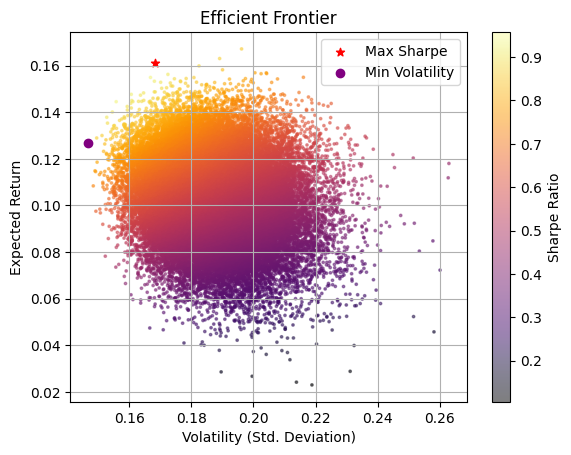

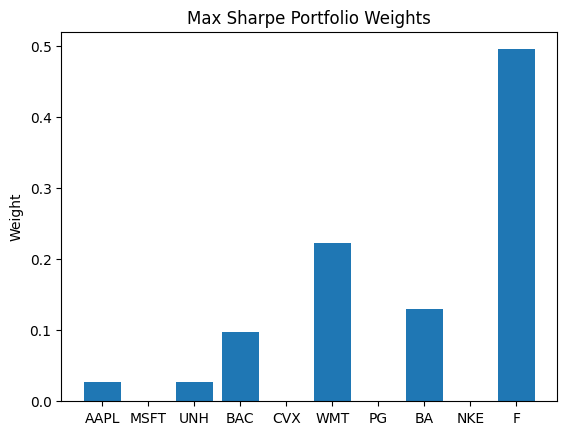

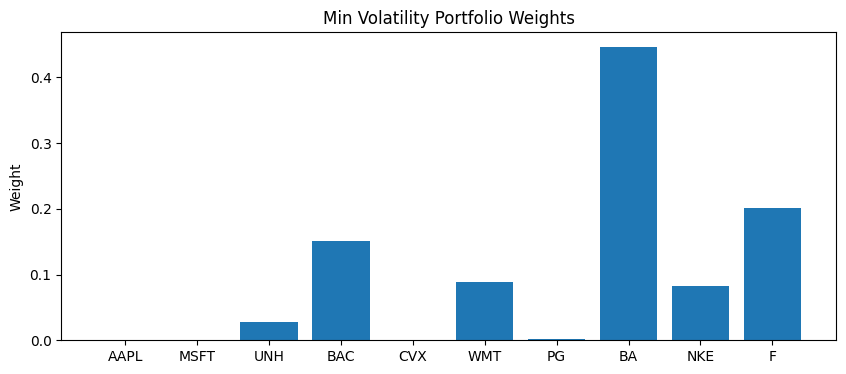

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#step1
tickers = ["AAPL", "MSFT", "UNH", "BAC", "CVX", "WMT", "PG", "BA", "NKE", "F"]

#step2
data  = yf.download( tickers, period = "5y")["Close"]
data = data.ffill().bfill()
data.dropna(inplace = True)

#step3
#dailylogreturns
dailylog = np.log(data/data.shift(1))
dailylog.dropna(inplace = True)
#annualized mean returns
amr = dailylog.mean() *252
#annualized covariance matrix
acm = dailylog.cov() *252

#step4
noofport = 50000
meanreturn = amr.values
covmatrix = acm.values
n = len(meanreturn)
expectedreturn = []
volatility =[]
sharpe = []
weights =[]

for i in range(noofport):
    weight = np.random.random(n)
    weight /= np.sum(weight)
    weights.append(weight)
    volatility.append(np.sqrt(np.dot(weight.T, np.dot(covmatrix, weight))))
    sharpe.append(np.dot(meanreturn, weight)/np.sqrt(np.dot(weight.T, np.dot(covmatrix, weight))))
    expectedreturn.append(np.dot(meanreturn, weight))

df = pd.DataFrame({'Returns':expectedreturn, 'Volatility':volatility, 'Sharpe Ratio':sharpe})
weightsdf = pd.DataFrame(weights, columns =[f'Weight{t}' for t in tickers])
df = pd.concat([df,weightsdf],axis=1)

maxsharpeindex = df['Sharpe Ratio'].idxmax()
minvolitalityindex = df['Volatility'].idxmin()
maxsharpe = df.loc[maxsharpeindex]
minvolatility = df.loc[minvolitalityindex]

#step5
plt.scatter(df['Volatility'], df['Returns'], c=df['Sharpe Ratio'], cmap='inferno', s=3, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(maxsharpe['Volatility'], maxsharpe['Returns'], color='r', marker='*', label='Max Sharpe')
plt.scatter(minvolatility['Volatility'], minvolatility['Returns'], color='purple', marker='o', label='Min Volatility')
plt.title('Efficient Frontier')
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.show()

#step6
def portfolioperformance(weights):
    expreturn = np.dot(weights, meanreturn)
    vol = np.sqrt(np.dot(weights.T, np.dot(covmatrix, weights)))
    return expreturn, vol

def minsharperatio(weights):
    expreturn, vol = portfolioperformance(weights)
    return -expreturn / vol

def portfoliovolatility(weights):
    return portfolioperformance(weights)[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for i in range(n))
initguess = n * [1. / n]
sharpe = minimize(minsharperatio, initguess, method='SLSQP', bounds=bounds, constraints=constraints)
minvol = minimize(portfoliovolatility, initguess, method='SLSQP', bounds=bounds, constraints=constraints)
sharpeweights = sharpe.x
minvolweights = minvol.x

#step7
plt.bar(tickers, sharpeweights)
plt.title("Max Sharpe Portfolio Weights")
plt.ylabel("Weight")
plt.show()
plt.figure(figsize=(10, 4))
plt.bar(tickers, minvolweights)
plt.title("Min Volatility Portfolio Weights")
plt.ylabel("Weight")
plt.show()
